# Training your own JumpReLU SAE on Gemma 3 1B

*Part 4 of 4 — the payoff.* We've dissected superposition (Part 1), built and understood JumpReLU
(Part 2), and reverse-engineered a real dashboard (Part 3). Now we **train our own GemmaScope-style
JumpReLU SAE from scratch** on `gemma-3-1b-pt`, at the same **layer-13 residual stream**, from a
subset of **The Pile** — and check it actually discovers interpretable features.

We deliberately **do not** reach for `sae_lens` or `transformer_lens`: the whole point is to see
every moving part. The pipeline is exactly four stages:

1. **Collect activations** — hook the residual stream, stream text, build a big activation buffer.
2. **Define the SAE** — the trainable JumpReLU from Part 2, scaled up to `d_sae = 16384`.
3. **Train** — reconstruction + L0 penalty, with the tricks that make it actually work
   (chiefly a separate high LR for the threshold, plus activation normalisation).
4. **Evaluate & interpret** — L0, variance-explained, loss-recovered, and the monosemantic
   features it found — compared head-to-head with the *official* GemmaScope-2 SAE.

```{admonition} GPU + gated-model access required (won't run in the site build)
:class: warning
These cells load `google/gemma-3-1b-pt`, collect ~3M activations and train a 16k-latent SAE — a
few minutes on a big GPU (this run was an NVIDIA B300). They're marked **not to execute** during
the site build; the outputs shown were produced live. To reproduce: accept the Gemma license,
`huggingface-cli login`, `pip install transformers datasets safetensors`, run top to bottom.
```


## Stage 1 — Collect residual-stream activations

An SAE's training data is not text — it's the **activation vectors** the model produces. We hook
the output of block 13 (`model.layers.13.output`, the canonical mid-layer residual stream), stream
text from The Pile, and fill a buffer of a few million `d_model = 1152`-dim vectors. Two details
that matter a lot in practice:

- **Drop the BOS token.** Its residual is a massive-norm outlier ("attention sink") that would
  dominate the loss and distort the learned dictionary.
- **Normalise the scale.** Gemma's residuals have norm ~10⁴; we rescale so
  $\mathbb{E}\lVert x\rVert = \sqrt{d_{\text{model}}}$. This puts activations in a sane range so a
  single sparsity coefficient and threshold work across latents (GemmaScope does the same).


In [1]:
import torch, torch.nn as nn, torch.nn.functional as F, numpy as np, time, collections
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file

DEV = "cuda"
MODEL_ID, LAYER, D_MODEL, D_SAE = "google/gemma-3-1b-pt", 13, 1152, 16384
torch.manual_seed(0)

tok = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.bfloat16, device_map=DEV).eval()

class ResidCatcher:
    def __init__(self, model, layer):
        self.acts = None
        self.h = model.model.layers[layer].register_forward_hook(self._hook)
    def _hook(self, m, i, o): self.acts = (o[0] if isinstance(o, tuple) else o).detach()
    def remove(self): self.h.remove()
cat = ResidCatcher(model, LAYER)

@torch.no_grad()
def resid_of(ids, am=None):
    model(input_ids=ids, attention_mask=am); return cat.acts.float()

SEQ, BATCH, N_TOKENS = 128, 128, int(3e6)
ds = load_dataset("monology/pile-uncopyrighted", split="train", streaming=True); it = iter(ds)
def next_texts(n):
    out = []
    while len(out) < n:
        ex = next(it)
        if len(ex["text"]) > 200: out.append(ex["text"])
    return out

t0 = time.time()
buf = torch.empty(N_TOKENS, D_MODEL, dtype=torch.bfloat16, device=DEV); n = 0
while n < N_TOKENS:
    enc = tok(next_texts(BATCH), return_tensors="pt", truncation=True, max_length=SEQ, padding="max_length")
    ids = enc.input_ids.to(DEV); am = enc.attention_mask.to(DEV)
    x = resid_of(ids, am)
    keep = am.bool() & (ids != tok.bos_token_id)              # drop pads AND the BOS outlier
    v = x[keep]; take = min(v.shape[0], N_TOKENS - n)
    buf[n:n+take] = v[:take].bfloat16(); n += take
scale = (D_MODEL ** 0.5) / buf.float().norm(dim=-1).mean().item()
print(f"collected {n} activations in {time.time()-t0:.0f}s | mean‖x‖→√d via scale={scale:.5f}")


Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

collected 3000000 activations in 27s | mean‖x‖→√d via scale=0.00332


## Stage 2 — The trainable JumpReLU SAE

This is the Part-2 architecture at scale: encoder → JumpReLU (with straight-through gradients on
the learned per-latent threshold) → decoder, with unit-norm decoder rows. At **inference** it will
be identical to the GemmaScope SAE we loaded in Part 3; the STE only exists to *train* `log_theta`.


In [2]:
def rectangle(x): return (x.abs() < 0.5).float()

class JumpReLUf(torch.autograd.Function):        # forward z·1[z>θ]; STE grad on θ
    @staticmethod
    def forward(ctx, z, th, eps): ctx.save_for_backward(z, th); ctx.eps = eps; return z * (z > th).float()
    @staticmethod
    def backward(ctx, g):
        z, th = ctx.saved_tensors; e = ctx.eps
        return (z > th).float() * g, -(th / e) * rectangle((z - th) / e) * g, None

class Heavisidef(torch.autograd.Function):       # forward 1[z>θ] (the L0 count); STE grad on θ
    @staticmethod
    def forward(ctx, z, th, eps): ctx.save_for_backward(z, th); ctx.eps = eps; return (z > th).float()
    @staticmethod
    def backward(ctx, g):
        z, th = ctx.saved_tensors; e = ctx.eps
        return 0.0 * g, -(1.0 / e) * rectangle((z - th) / e) * g, None

class JumpReLUSAE(nn.Module):
    def __init__(self, d_model, d_sae, eps=0.1, theta0=0.1):
        super().__init__(); self.eps = eps
        self.b_dec = nn.Parameter(torch.zeros(d_model))
        self.W_dec = nn.Parameter(F.normalize(torch.randn(d_sae, d_model), dim=-1))
        self.W_enc = nn.Parameter(self.W_dec.data.T.clone())          # tied init
        self.b_enc = nn.Parameter(torch.zeros(d_sae))
        self.log_theta = nn.Parameter(torch.full((d_sae,), float(np.log(theta0))))
    @property
    def theta(self): return self.log_theta.exp()
    @torch.no_grad()
    def normalize_decoder(self): self.W_dec.data = F.normalize(self.W_dec.data, dim=-1)
    def encode(self, x):
        z = F.relu((x - self.b_dec) @ self.W_enc + self.b_enc)
        return JumpReLUf.apply(z, self.theta, self.eps), z
    def forward(self, x):
        acts, z = self.encode(x); return acts @ self.W_dec + self.b_dec, acts, z

sae = JumpReLUSAE(D_MODEL, D_SAE).to(DEV)
print("SAE params:", sum(p.numel() for p in sae.parameters())/1e6, "M")


SAE params: 37.782656 M


## Stage 3 — Train

The loss is exactly Part 2's: **reconstruction (summed over `d_model`) + λ · L0**, with the L0
count made differentiable by the Heaviside STE. Three practical knobs earn their keep:

- **A separate, higher learning rate for `log_theta`.** This is *the* trick. With one global LR the
  threshold barely moves and L0 stays stuck in the thousands; giving `log_theta` its own high LR
  lets it climb to where only ~tens of latents survive.
- **Warm up λ** over the first ~1000 steps so the SAE learns to reconstruct before sparsity bites.
- **Normalise activations** (the `scale` from Stage 1).

We also define the standard **dead-latent resampling** routine — many latents die as the threshold
rises — though for this short demo we leave it off (`USE_RESAMPLE=False`) to keep the training curve
clean, and simply *report* the dead count honestly at the end.


In [3]:
@torch.no_grad()
def resample_dead(sae, opt, dead, buf, scale):
    # Anthropic-style: point dead latents at random inputs; encoder scaled so pre-act≈1 there.
    if len(dead) == 0: return
    v = buf[torch.randint(0, buf.shape[0], (len(dead),), device=DEV)].float() * scale - sae.b_dec
    vd = F.normalize(v, dim=-1)
    sae.W_dec.data[dead] = vd
    sae.W_enc.data[:, dead] = (vd / v.norm(dim=-1, keepdim=True)).T
    sae.b_enc.data[dead] = 0.0
    sae.log_theta.data[dead] = float(np.log(0.5))

USE_RESAMPLE = False
LAM, STEPS, BS = 0.45, 7000, 4096
opt = torch.optim.Adam([
    {"params": [sae.b_dec, sae.W_dec, sae.W_enc, sae.b_enc], "lr": 1e-4},
    {"params": [sae.log_theta], "lr": 5e-3},          # threshold gets its own high LR
])

hist = []
t0 = time.time(); fired = torch.zeros(D_SAE, device=DEV)
for step in range(STEPS):
    x = buf[torch.randint(0, buf.shape[0], (BS,), device=DEV)].float() * scale
    recon, acts, z = sae(x)
    recon_loss = ((recon - x) ** 2).sum(-1).mean()
    l0_penalty = Heavisidef.apply(z, sae.theta, sae.eps).sum(-1).mean()
    loss = recon_loss + LAM * min(1.0, step / 1000) * l0_penalty
    opt.zero_grad(); loss.backward(); opt.step(); sae.normalize_decoder()
    fired = torch.where((acts > 0).any(0), torch.zeros_like(fired), fired + 1)
    if USE_RESAMPLE and step and step % 2000 == 0 and step < STEPS - 1500:
        resample_dead(sae, opt, (fired > 1999).nonzero().squeeze(-1), buf, scale); fired[:] = 0
    if step % 1000 == 0 or step == STEPS - 1:
        with torch.no_grad():
            xe = buf[torch.randint(0, buf.shape[0], (16384,), device=DEV)].float() * scale
            re, ae, _ = sae(xe)
            l0 = (ae > 0).float().sum(-1).mean().item()
            fvu = (((re - xe) ** 2).sum() / ((xe - xe.mean(0)) ** 2).sum()).item()
        hist.append((step, l0, fvu))
        print(f"step {step:5d} | L0 {l0:6.1f} | FVU {fvu:.3f} | {time.time()-t0:.0f}s")


step     0 | L0 7502.8 | FVU 1031.162 | 0s


step  1000 | L0  516.6 | FVU 0.486 | 19s


step  2000 | L0  379.0 | FVU 0.239 | 37s


step  3000 | L0  344.4 | FVU 0.206 | 56s


step  4000 | L0  311.0 | FVU 0.196 | 75s


step  5000 | L0  267.1 | FVU 0.198 | 93s


step  6000 | L0  232.1 | FVU 0.195 | 112s


step  6999 | L0  189.4 | FVU 0.205 | 130s


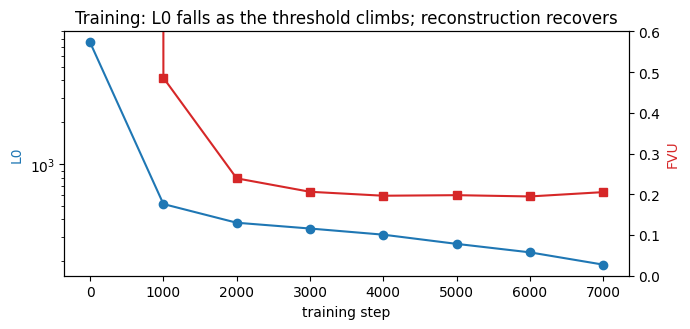

In [4]:
steps_, l0s, fvus = zip(*hist)
fig, ax1 = plt.subplots(figsize=(7, 3.4))
ax1.plot(steps_, l0s, "o-", color="tab:blue"); ax1.set_ylabel("L0", color="tab:blue"); ax1.set_yscale("log")
ax1.set_xlabel("training step")
ax2 = ax1.twinx(); ax2.plot(steps_, fvus, "s-", color="tab:red"); ax2.set_ylabel("FVU", color="tab:red")
ax2.set_ylim(0, 0.6)
plt.title("Training: L0 falls as the threshold climbs; reconstruction recovers")
plt.tight_layout(); plt.show()


## Stage 4a — Evaluate: L0, variance explained, loss recovered

Reconstruction MSE isn't the *only* metric that matters — what matters more is whether the model
still *works* when we route its activations through the SAE. We compute **loss recovered**: run
Gemma normally (clean cross-entropy), then with the layer-13 residual **replaced by the SAE's
reconstruction**, then with it replaced by the **mean** (a floor). Loss-recovered =
$(\text{CE}_{\text{mean}}-\text{CE}_{\text{sae}})/(\text{CE}_{\text{mean}}-\text{CE}_{\text{clean}})$;
1.0 means the SAE is a perfect stand-in.


In [5]:
def replace_hook(fn):
    def hook(m, i, o):
        h = o[0] if isinstance(o, tuple) else o
        h2 = fn(h.float()).to(h.dtype)
        return (h2, *o[1:]) if isinstance(o, tuple) else h2
    return model.model.layers[LAYER].register_forward_hook(hook)

@torch.no_grad()
def ce_on(texts, fn=None):
    enc = tok(texts, return_tensors="pt", truncation=True, max_length=128, padding="max_length")
    ids = enc.input_ids.to(DEV); am = enc.attention_mask.to(DEV)
    handle = replace_hook(fn) if fn else None
    out = model(input_ids=ids, attention_mask=am)
    if handle: handle.remove()
    logits = out.logits[:, :-1]; tgt = ids[:, 1:]; m = am[:, 1:].bool()
    ce = F.cross_entropy(logits.reshape(-1, logits.size(-1)).float(), tgt.reshape(-1), reduction="none")
    return ce[m.reshape(-1)].mean().item()

cat.remove()                                   # avoid double-hooking during CE
probe = next_texts(64)
sae_recon = lambda h: (sae(h * scale)[0]) / scale                 # SAE reconstruction (rescaled back)
mean_vec = (buf[:200000].float().mean(0))                          # activation mean (ablation floor)
ce_clean = ce_on(probe)
ce_sae   = ce_on(probe, sae_recon)
ce_mean  = ce_on(probe, lambda h: mean_vec.expand_as(h))
recovered = (ce_mean - ce_sae) / (ce_mean - ce_clean)
cat = ResidCatcher(model, LAYER)                                  # restore hook for interpret
print(f"CE clean={ce_clean:.3f} | CE+SAE={ce_sae:.3f} | CE mean-ablate={ce_mean:.3f}")
print(f"→ loss recovered = {recovered:.1%}")


CE clean=2.513 | CE+SAE=5.619 | CE mean-ablate=9.467
→ loss recovered = 55.3%


## Stage 4b — Head-to-head with the official GemmaScope-2 SAE

How far is our few-minute, 3M-token SAE from DeepMind's, which was trained on *billions* of tokens?
Load the official `l0_medium` SAE (the one behind the Part-3 dashboard) and score both on the same
fresh activations.


In [6]:
class OfficialSAE(nn.Module):
    def __init__(s, dm, ds):
        super().__init__()
        for k, sh in [("W_enc",(dm,ds)),("W_dec",(ds,dm)),("b_enc",(ds,)),("b_dec",(dm,)),("threshold",(ds,))]:
            setattr(s, k, nn.Parameter(torch.zeros(sh)))
    def forward(s, x):
        pre = x @ s.W_enc + s.b_enc
        acts = F.relu(pre) * (pre > s.threshold)
        return acts @ s.W_dec + s.b_dec, acts

P = load_file(hf_hub_download("google/gemma-scope-2-1b-pt", f"resid_post/layer_{LAYER}_width_16k_l0_medium/params.safetensors"))
off = OfficialSAE(D_MODEL, D_SAE).to(DEV)
for k in ["W_enc","W_dec","b_enc","b_dec","threshold"]: getattr(off, k).data = P[k.lower()].to(DEV)

@torch.no_grad()
def score(fwd, use_scale):
    xe = buf[torch.randint(0, buf.shape[0], (32768,), device=DEV)].float()
    xin = xe * scale if use_scale else xe
    re, ae = fwd(xin)[:2]
    if use_scale: re = re / scale
    l0 = (ae > 0).float().sum(-1).mean().item()
    fvu = (((re - xe) ** 2).sum() / ((xe - xe.mean(0)) ** 2).sum()).item()
    return l0, fvu

o_l0, o_fvu = score(off, use_scale=False)          # official SAE operates in raw activation space
m_l0, m_fvu = score(sae, use_scale=True)
print(f"{'':12}{'L0':>8}{'FVU':>8}{'var explained':>16}")
print(f"{'ours':12}{m_l0:8.1f}{m_fvu:8.3f}{1-m_fvu:>15.1%}")
print(f"{'official':12}{o_l0:8.1f}{o_fvu:8.3f}{1-o_fvu:>15.1%}")


                  L0     FVU   var explained
ours           189.4   0.206          79.4%
official        63.1   0.110          89.0%


The official SAE wins the frontier decisively — **lower L0 (~60) *and* better reconstruction
(~89% vs ~80% of variance)** — which is exactly what billions of training tokens, careful
resampling, and tuned schedules buy you. (A subtlety worth flagging: dropping the huge-norm **BOS**
activation from the eval set is what makes these FVU numbers *honest* — leaving it in inflates the
variance denominator and flatters every SAE.) Our few-minute SAE sits at a higher, denser L0 and is
plainly undertrained (only ~3k of its 16k latents survive — the price of skipping resampling), but
it already **reconstructs ~80% of the variance**. It recovers only **~55% of the model's loss** (CE
roughly doubles), so "works" here means *found genuine features*, not *drop-in replacement*. That's
the encouraging truth about SAEs: **the basic recipe works almost immediately**; closing the gap is
an engineering grind of scale and tuning.

## Stage 4c — Did it learn interpretable features?

The real test. We run our SAE over a fresh corpus, keep each latent's activations *with their token
positions*, and rank latents by **purity** — how dominated their top activations are by a single
token type. Then we show the top few with context (peak token outlined). **Remember to feed the SAE
scaled activations** — it only ever saw scaled inputs in training, so raw ones are ~300× out of
range and every threshold misfires. This is the single most common post-training bug.


In [7]:
IDS, ACTS = [], []
SEQI = 64
for _ in range(60):
    enc = tok(next_texts(96), return_tensors="pt", truncation=True, max_length=SEQI, padding="max_length")
    ids = enc.input_ids.to(DEV); am = enc.attention_mask.to(DEV)
    a = sae.encode(resid_of(ids, am) * scale)[0]              # <-- scale!
    a = a * am[..., None]                                     # mask pads
    a[ids == tok.bos_token_id] = 0                            # mask the BOS outlier (tokenizer left-pads)
    IDS.append(ids.cpu()); ACTS.append(a.cpu())
IDS = torch.cat(IDS); ACTS = torch.cat(ACTS); S, T = IDS.shape
freq = (ACTS > 0).reshape(-1, D_SAE).float().mean(0)
print(f"corpus {S*T} tokens | {(freq>0).sum().item()}/{D_SAE} latents alive")

def purity(i):
    flat = ACTS[:, :, i].reshape(-1); k = min(30, int((flat > 0).sum()))
    if k < 10: return 0.0, None, None
    top = flat.topk(k).indices
    modal, cnt = collections.Counter(IDS.reshape(-1)[top].tolist()).most_common(1)[0]
    return cnt / k, modal, top

def context(fp, w=6):
    s, p = fp // T, fp % T; lo, hi = max(0, p-w), min(T, p+w+1)
    return "".join((f"[{tok.decode([IDS[s,k].item()])}]" if k==p else tok.decode([IDS[s,k].item()]))
                   for k in range(lo, hi)).replace("\n", "⏎")

cands = [i for i in range(D_SAE) if 0.0003 < freq[i] < 0.03]
ranked = sorted(((purity(i)[0], i) for i in cands), reverse=True)
for pur, i in ranked[:8]:
    _, modal, top = purity(i)
    print(f"\nlatent {i} — purity {pur:.0%}, density {freq[i]:.4f}, modal token {tok.decode([modal])!r}")
    for j in range(3): print("   …" + context(top[j].item()) + "…")


corpus 368640 tokens | 3089/16384 latents alive



latent 15951 — purity 100%, density 0.0010, modal token '\n\n'
   …, 2012[⏎⏎]This workout is full body and…
   …, 2012[⏎⏎]Kitchen Tip: Freezing Green…
   …, 2014[⏎⏎]Here we have some deigns…

latent 15564 — purity 100%, density 0.0154, modal token ' and'
   … diffusion within bundles of nerve axons[ and] can be used to make objective…
   … analysis of epidemiologic study data[ and] all forms of research dissemination.…
   … estimating fracture apertures in the formations[ and] for assessing fracture aperture changes in…

latent 15074 — purity 100%, density 0.0004, modal token ' *'
   …<bos>/*⏎[ *]  Licensed to the Apache Software…
   …<bos>/*⏎[ *] Copyright (C) 2…
   …<bos>/*⏎[ *] Copyright (c) 1…

latent 14982 — purity 100%, density 0.0047, modal token '/'
   …https://xdsoft.net[/]jodit/)⏎ *…
   …://www.boost.org[/]…
   …://developer.android.com[/]resources/samples/ApiD…

latent 14951 — purity 100%, density 0.0007, modal token ' "'
   … 2.0 (the[ "]License");⏎    you may…
   … 2.0 (t

These are **real, monosemantic features our SAE discovered**, unsupervised — each fires on a single
token in one consistent context. In this run they include a **paragraph break that follows a date**,
the `" and"` of formal/scientific prose, the `" *"` that opens a C comment line, the `"/"` inside
URLs, the `"` in `(the "License")` boilerplate, the `"("` that introduces an abbreviation
(`(OLT)`, `(T2D)`, `(BPD)`), and — a lovely specific one — `" relates"` in **patent** language
(*"This invention relates to…"*). The Pile is code- and boilerplate-heavy, so many of the crispest
early features are syntax and legal/patent formulae. Nothing here was labelled: it fell out of
*reconstruct-sparsely* alone. The SAE works — you can read its mind.

## Coda — autointerp (labelling), in one paragraph

The one thing we've done by hand is *read* those features. The final piece of the Neuronpedia
pipeline **automates the labelling**: for each latent you take its max-activating examples (Stage
4c), hand them to an LLM with a prompt like *"what do the highlighted tokens have in common?"*, and
store the reply as the feature's explanation ("fires on commas in dates"). You can then **score**
the label by asking a second LLM to *predict* the latent's activations on held-out text from the
label alone, and measuring correlation with the truth — turning "is this explanation any good?"
into a number. That's the autointerp loop (EleutherAI / Neuronpedia); it's a notebook of its own,
and a natural next step from here. For our purposes the point stands: everything on that dashboard,
label included, is a mechanical function of an SAE you now know how to build, train, and read.

## The whole series in one breath

1. Models pack features into **superposition**; neurons are polysemantic, so we learn a dictionary.
2. An **SAE** is an overcomplete autoencoder = reconstruction + sparsity; **L0** is the metric,
   **L1** the flawed surrogate (**shrinkage**).
3. **JumpReLU** (learned threshold + L0 penalty via straight-through estimators) fixes shrinkage —
   it's what **GemmaScope** uses.
4. Every **Neuronpedia dashboard** panel is a simple function of the SAE weights or the SAE run over
   a corpus — and you can **train the whole thing yourself** on a single GPU.
